# Plot Trained Model Predictions by Time Slice

Use this notebook to select one or more timestamps, load the matching model predictions from `../outputs/Our_results_trained_models_2mT.pkl`, and compare selected models. The plotting palette is `viridis`, matching the original `imshow` style and the GIF export in `models_inference.ipynb`. Set `use_fixed_color_scale = False` for GIF-style local percentile clipping and higher contrast on each selected time slice.

In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Work from the notebook location.
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != 'notebooks':
    NOTEBOOK_DIR = Path('notebooks') if Path('notebooks').exists() else NOTEBOOK_DIR

RESULTS_FILE = (NOTEBOOK_DIR / '../outputs/Our_results_trained_models_2mT.pkl').resolve()
TARGET_VAR = '2mT'
PLOT_VAR = '2mT'
# models_inference.ipynb uses imshow's default palette, and the GIF export uses viridis explicitly.
CMAP = 'viridis'

print(f'Loading: {RESULTS_FILE}')
results_df = pd.read_pickle(RESULTS_FILE)
results_df['time_step'] = pd.to_datetime(results_df['time_step'])

results_df.head()

Loading: /home/chuongtnd/git-repo/Physically-conditioned-latent-diffusion-model-for-temperature/outputs/Our_results_trained_models_2mT.pkl


,input_var,target_var,model,variable,spat_distr,min,max,time_step
0,all,2mT,ERA5,2mT,"[[tensor(282.5619), tensor(282.8127), tensor(2...",272.341272,290.437225,2014-04-24 02:00:00
1,all,2mT,ERA5,2mT,"[[tensor(273.5626), tensor(274.1877), tensor(2...",258.988051,289.312317,2014-12-28 03:00:00
2,all,2mT,ERA5,2mT,"[[tensor(287.2497), tensor(287.8748), tensor(2...",281.060699,300.498718,2019-09-02 02:00:00
3,all,2mT,ERA5,2mT,"[[tensor(289.4377), tensor(289.6876), tensor(2...",275.939758,301.378571,2006-05-14 10:00:00
4,all,2mT,ERA5,2mT,"[[tensor(277.4988), tensor(278.2475), tensor(2...",269.379364,290.562653,2016-05-02 04:00:00


## Choose Time Slices and Models

Edit `time_slices` to the timestamps you want to inspect. Keep `model_order = None` to plot every available model, or provide an explicit list to control the row order.

In [20]:
# Example requested format: '2014-04-24 02:00:00'
time_slices = [
    '2014-04-24 02:00:00',
    '2014-12-28 03:00:00',
    '2016-05-02 04:00:00',
    '2006-05-14 10:00:00',
    '2019-09-02 02:00:00',
    
]

# Use None for all models in the file, or choose a subset/order, for example:
# model_order = ['ERA5', 'COSMO-CLM', 'UNET', 'GAN', 'LDM_res', 'LDM_PDE_res', 'LMM_PDE_res']
model_order = ['COSMO-CLM', 'UNET', 'GAN', 'LDM_res', 'LDM_PDE_res', 'LMM_PDE_res_last_1', 'LMM_PDE_res_004_1']

# Exclude models from the plot, for example: ['ERA5']
exclude_models = ['ERA5']

# True: one fixed scale across the full results file.
# False: use percentile clipping for each selected time slice, matching the GIF export style.
use_fixed_color_scale = False

# Percentiles used when use_fixed_color_scale=False. The GIF export in models_inference.ipynb uses (0.5, 99.5).
local_contrast_percentiles = (0.5, 99.5)

# Arrange each timestamp's model panels into this many rows.
n_model_rows = 2

selected_times = pd.to_datetime(time_slices)
selected_times

DatetimeIndex(['2014-04-24 02:00:00', '2014-12-28 03:00:00',
               '2016-05-02 04:00:00', '2006-05-14 10:00:00',
               '2019-09-02 02:00:00'],
              dtype='datetime64[ns]', freq=None)

In [21]:
plot_df = results_df[
    (results_df['target_var'] == TARGET_VAR)
    & (results_df['variable'] == PLOT_VAR)
].copy()

available_times = pd.Index(sorted(plot_df['time_step'].unique()))
available_models = list(plot_df['model'].drop_duplicates())

print(f'Available models ({len(available_models)}):')
print(available_models)
print(f'Available timestamps: {len(available_times)}')
print(f'First timestamp: {available_times[0]}')
print(f'Last timestamp:  {available_times[-1]}')

Available models (15):
['ERA5', 'COSMO-CLM', 'Quadratic Interp.', 'Linear Interp.', 'UNET', 'GAN', 'LDM_res', 'LDM_PDE_res', 'LMM_PDE_res', 'LMM_PDE_res_055_1', 'LMM_PDE_res_055_3', 'LMM_PDE_res_last_1', 'LMM_PDE_res_last_3', 'LMM_PDE_res_004_1', 'LMM_PDE_res_004_3']
Available timestamps: 165
First timestamp: 2000-01-01 15:00:00
Last timestamp:  2020-12-02 20:00:00


In [22]:
def as_array(value):
    """Convert saved tensors/xarray/numpy objects into a 2-D numpy array for imshow."""
    if hasattr(value, 'detach'):
        value = value.detach().cpu().numpy()
    elif hasattr(value, 'values'):
        value = value.values
    try:
        return np.asarray(value, dtype=float).squeeze()
    except (TypeError, ValueError):
        return np.asarray(value).squeeze()


def color_limits(df):
    """Use the saved robust percentiles for a stable global scale."""
    return float(df['min'].min()), float(df['max'].max())


def percentile_color_limits(df, percentiles=(0.5, 99.5)):
    """Match the GIF export style: percentile clipping over the arrays being plotted."""
    arrays = [as_array(value) for value in df['spat_distr']]
    stacked = np.stack(arrays, axis=0)
    vmin = float(np.nanpercentile(stacked, percentiles[0]))
    vmax = float(np.nanpercentile(stacked, percentiles[1]))
    return vmin, vmax


def resolve_models(df, model_order=None, exclude=None):
    available = list(df['model'].drop_duplicates())
    models = available if model_order is None else list(model_order)
    exclude = set(exclude or [])
    models = [model for model in models if model not in exclude]

    missing_models = [model for model in models if model not in set(available)]
    if missing_models:
        raise ValueError(f'Missing requested models: {missing_models}')
    if not models:
        raise ValueError('No models left to plot after applying exclude_models.')
    return models


def validate_times(df, times):
    available_times = set(df['time_step'])
    missing_times = [ts for ts in times if ts not in available_times]
    if missing_times:
        nearest = {
            str(ts): str(df.iloc[(df['time_step'] - ts).abs().argsort()[:1]]['time_step'].iloc[0])
            for ts in missing_times
        }
        raise ValueError(f'Missing requested timestamps. Nearest available matches: {nearest}')


def plot_time_slice(
    df,
    ts,
    models,
    use_fixed_scale=True,
    fixed_vmin=None,
    fixed_vmax=None,
    local_percentiles=(0.5, 99.5),
    n_rows=2,
    cmap=CMAP,
    figsize_per_panel=(3.6, 3.2),
    save_path=None,
):
    ts = pd.to_datetime(ts)
    time_df = df[df['time_step'] == ts]
    selected_df = time_df[time_df['model'].isin(models)]

    if use_fixed_scale:
        vmin, vmax = fixed_vmin, fixed_vmax
        scale_label = 'fixed global scale'
    else:
        vmin, vmax = percentile_color_limits(selected_df, percentiles=local_percentiles)
        scale_label = f'local percentile scale p{local_percentiles[0]}-p{local_percentiles[1]}'

    n_rows = max(1, min(int(n_rows), len(models)))
    n_cols = int(np.ceil(len(models) / n_rows))
    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(figsize_per_panel[0] * n_cols, figsize_per_panel[1] * n_rows),
        sharex=True,
        sharey=True,
        squeeze=False,
        constrained_layout=True,
    )

    image = None
    for idx, model in enumerate(models):
        row, col = divmod(idx, n_cols)
        ax = axes[row, col]
        match = time_df[time_df['model'] == model]
        if match.empty:
            ax.set_visible(False)
            continue

        arr = as_array(match.iloc[0]['spat_distr'])
        image = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(model, fontsize=11)
        ax.set_xticks([])
        ax.set_yticks([])

    for ax in axes.flat[len(models):]:
        ax.set_visible(False)

    cbar = fig.colorbar(image, ax=axes, shrink=0.85, pad=0.01)
    cbar.set_label(f'{PLOT_VAR} [K]')
    fig.suptitle(f'{PLOT_VAR} predictions | {ts} | {scale_label} ({vmin:.2f}, {vmax:.2f})', fontsize=14)

    if save_path is not None:
        save_path = Path(save_path)
        fig.savefig(save_path, dpi=180, bbox_inches='tight')
        print(f'Saved figure: {save_path}')

    return fig, axes


def plot_selected_time_slices(
    df,
    times,
    model_order=None,
    exclude_models=None,
    use_fixed_scale=True,
    local_percentiles=(0.5, 99.5),
    n_rows=2,
):
    times = list(pd.to_datetime(times))
    validate_times(df, times)
    models = resolve_models(df, model_order=model_order, exclude=exclude_models)

    fixed_vmin, fixed_vmax = color_limits(df)
    print(f'Plotting models: {models}')
    if use_fixed_scale:
        print(f'Using fixed global color scale: vmin={fixed_vmin:.3f}, vmax={fixed_vmax:.3f}')
    else:
        print(f'Using local percentile color scale: p{local_percentiles[0]}-p{local_percentiles[1]}')

    figures = []
    for ts in times:
        fig, axes = plot_time_slice(
            df,
            ts,
            models=models,
            use_fixed_scale=use_fixed_scale,
            fixed_vmin=fixed_vmin,
            fixed_vmax=fixed_vmax,
            local_percentiles=local_percentiles,
            n_rows=n_rows,
        )
        figures.append((fig, axes))
        plt.show()

    return figures

Plotting models: ['COSMO-CLM', 'UNET', 'GAN', 'LDM_res', 'LDM_PDE_res', 'LMM_PDE_res_last_1', 'LMM_PDE_res_004_1']
Using local percentile color scale: p0.5-p99.5


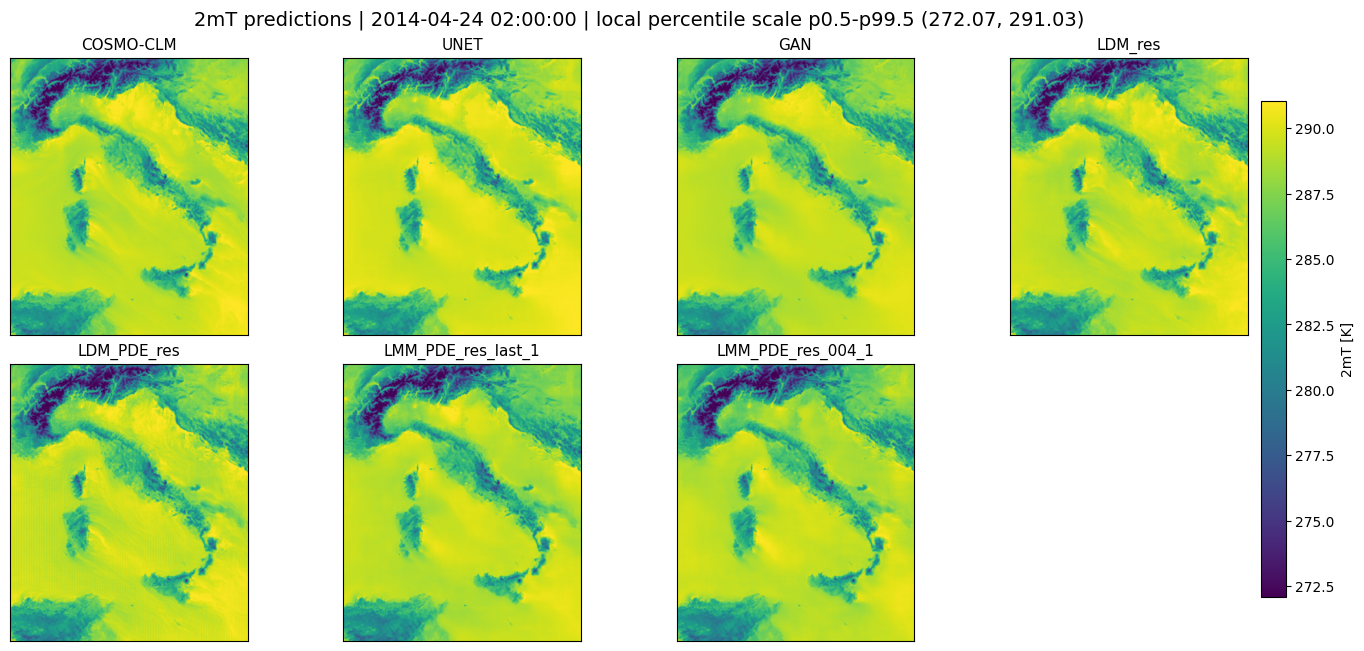

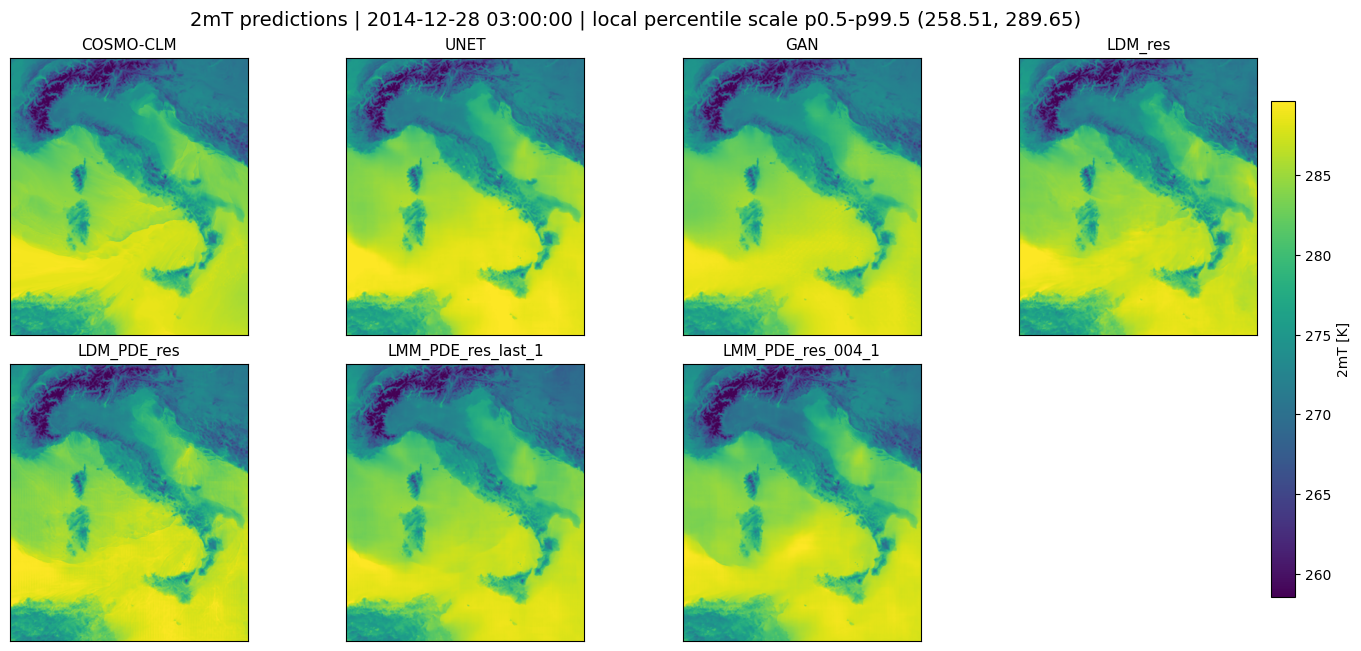

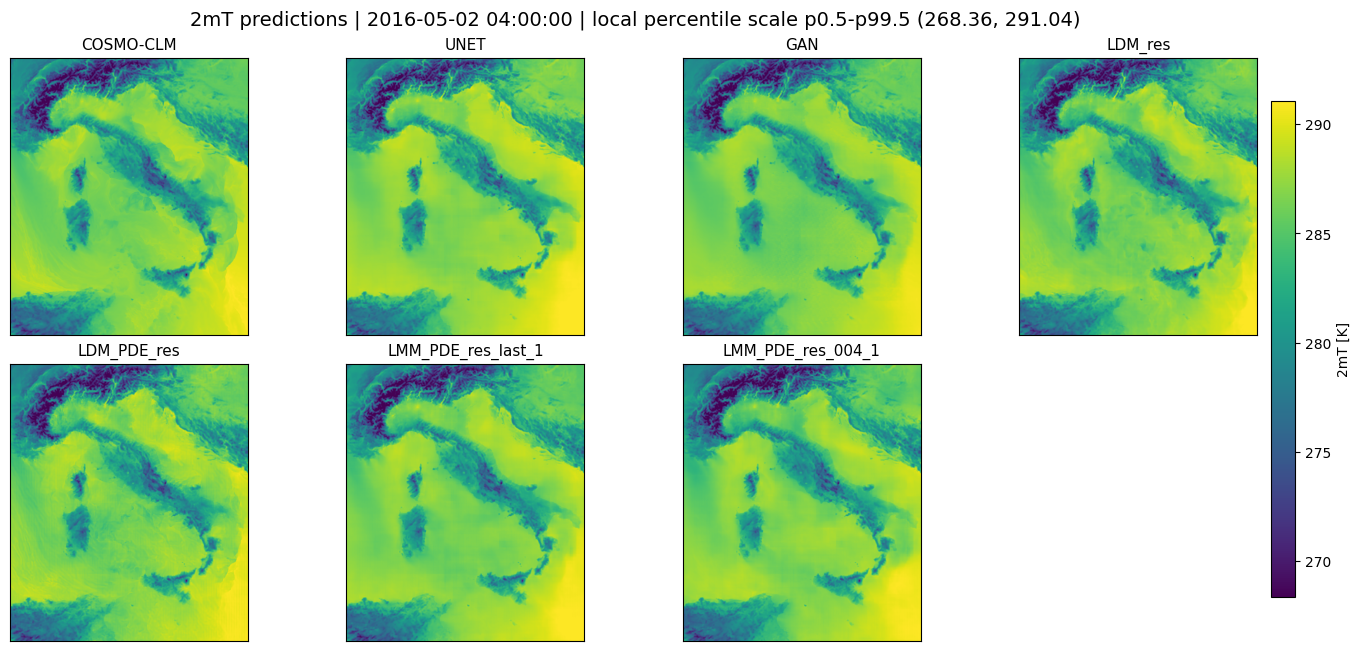

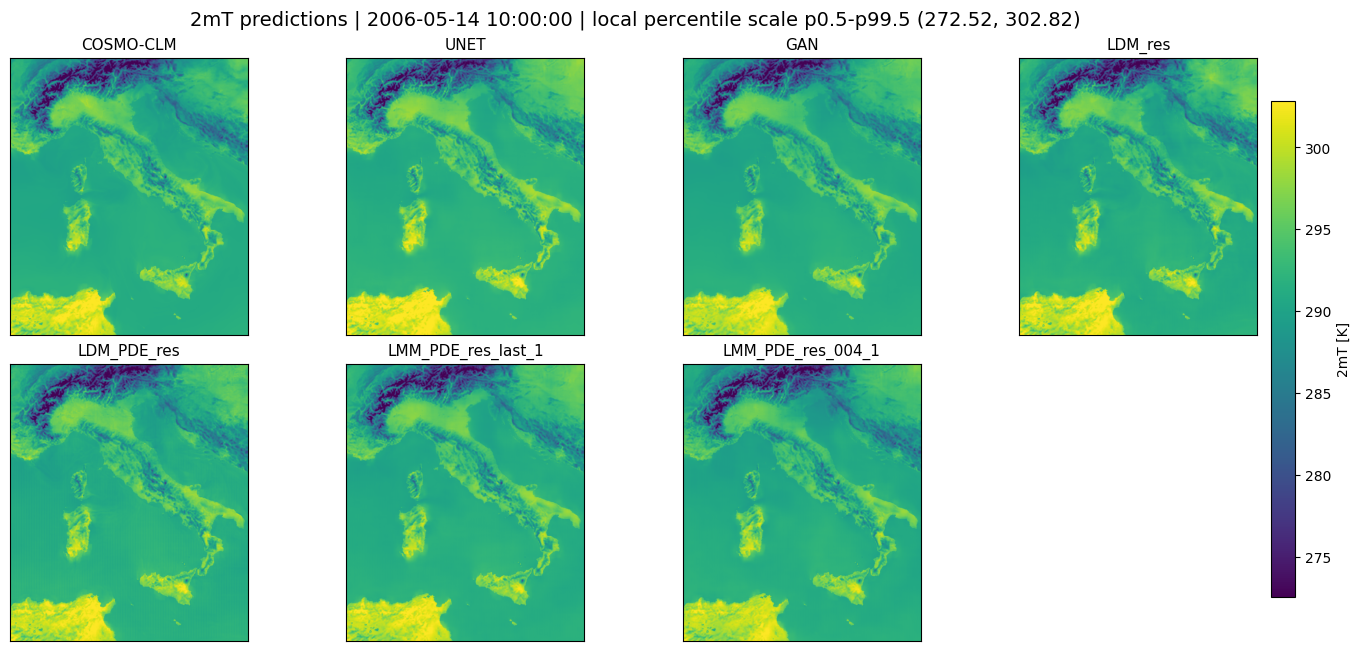

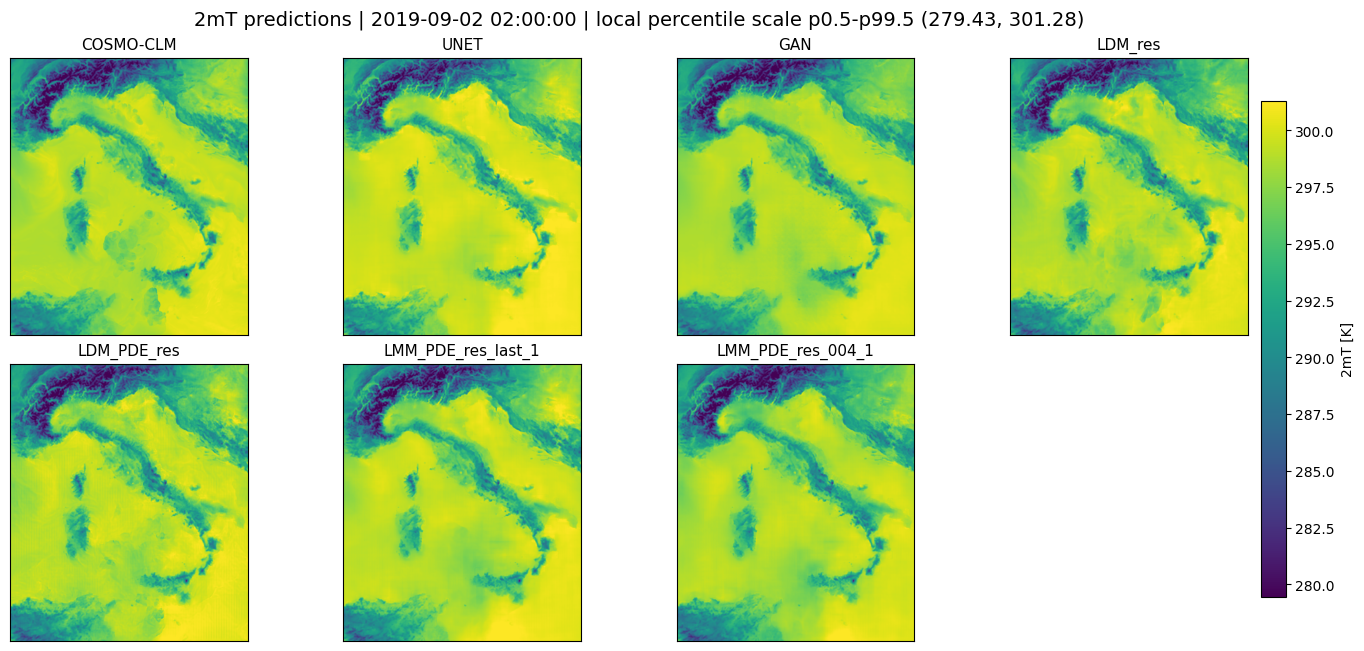

In [23]:
figures = plot_selected_time_slices(
    plot_df,
    selected_times,
    model_order=model_order,
    exclude_models=exclude_models,
    use_fixed_scale=use_fixed_color_scale,
    local_percentiles=local_contrast_percentiles,
    n_rows=n_model_rows,
)

## Optional: Plot Each Time Slice Separately

Run this cell when you want one figure per selected timestamp while preserving the same global color scale.

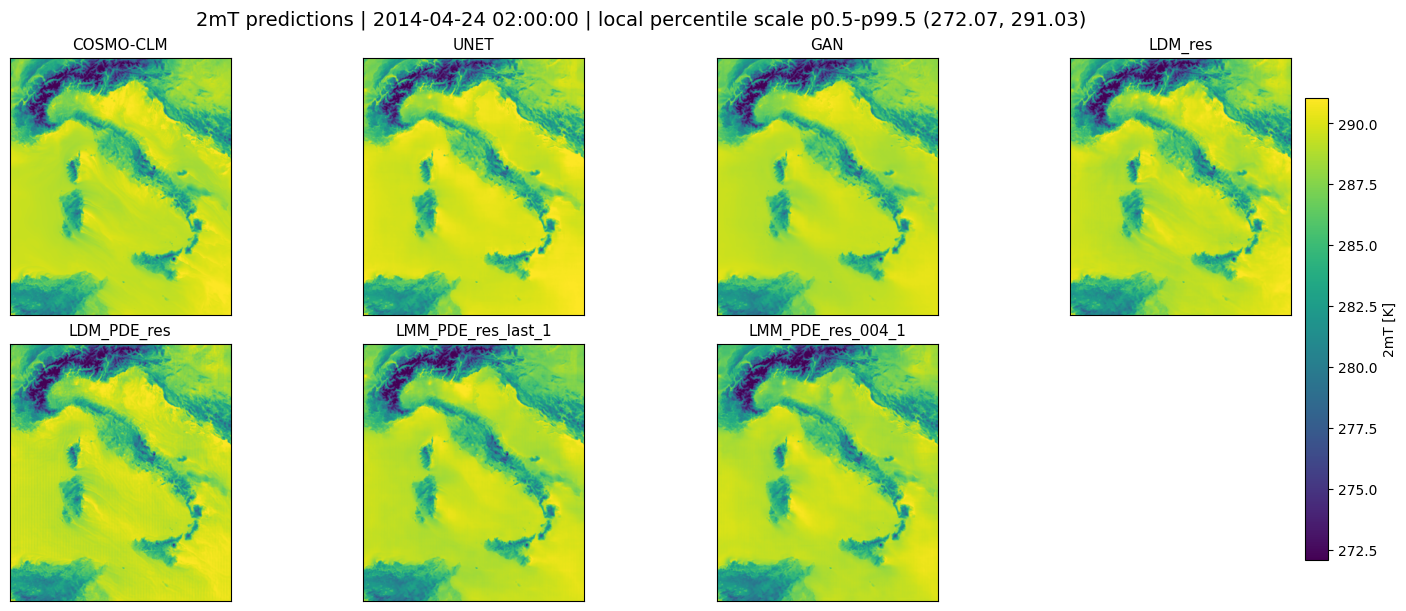

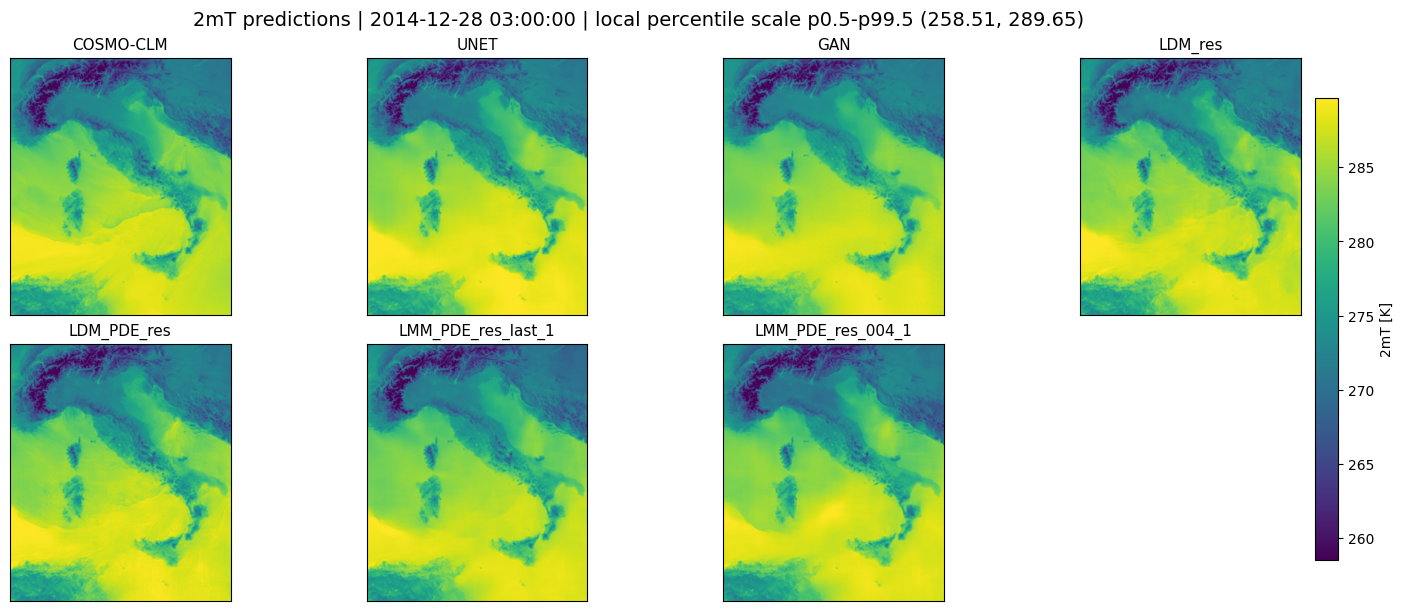

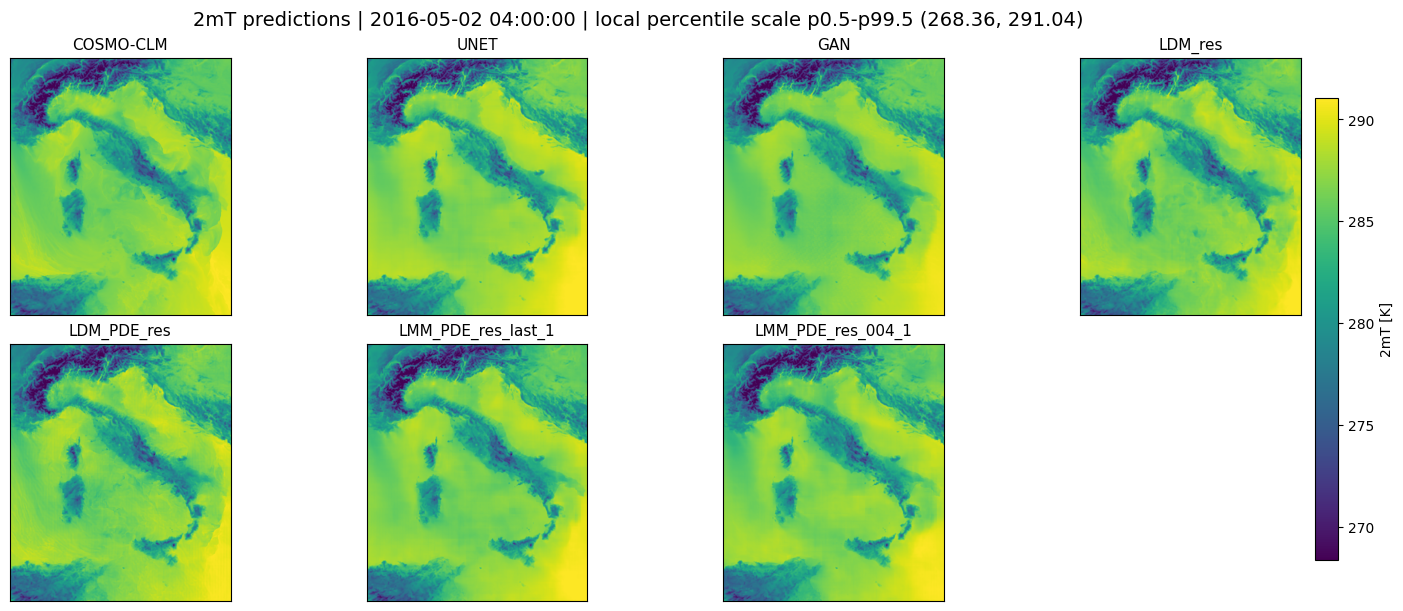

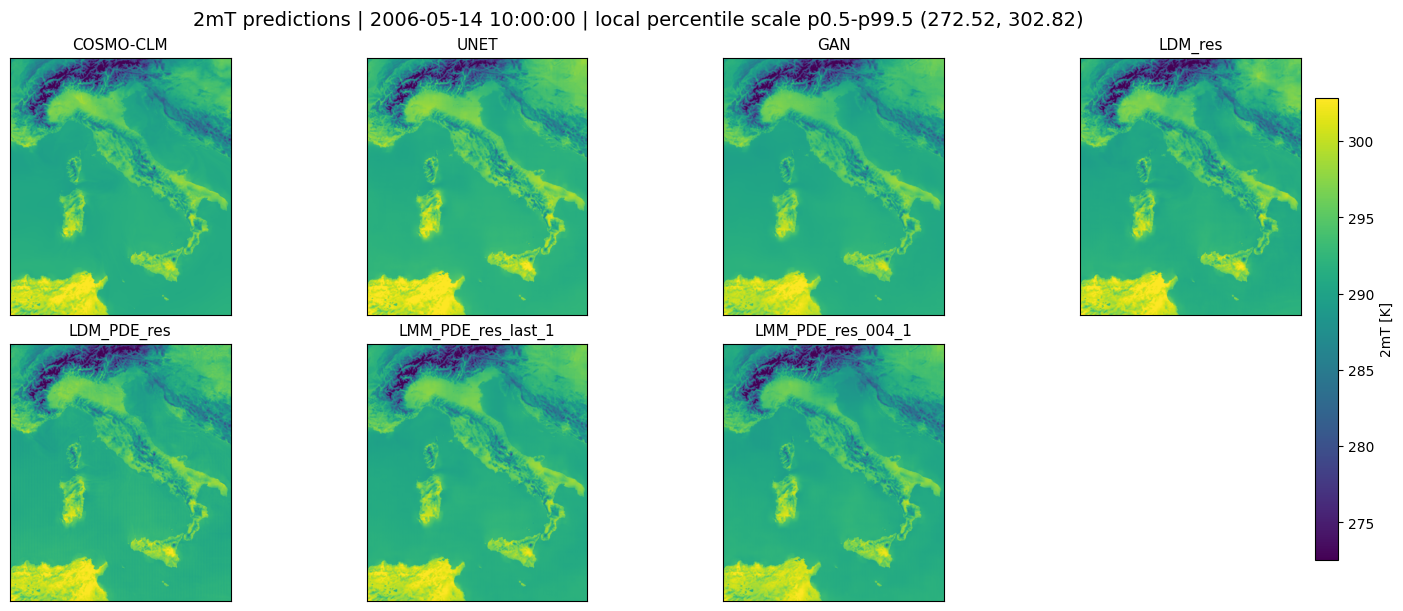

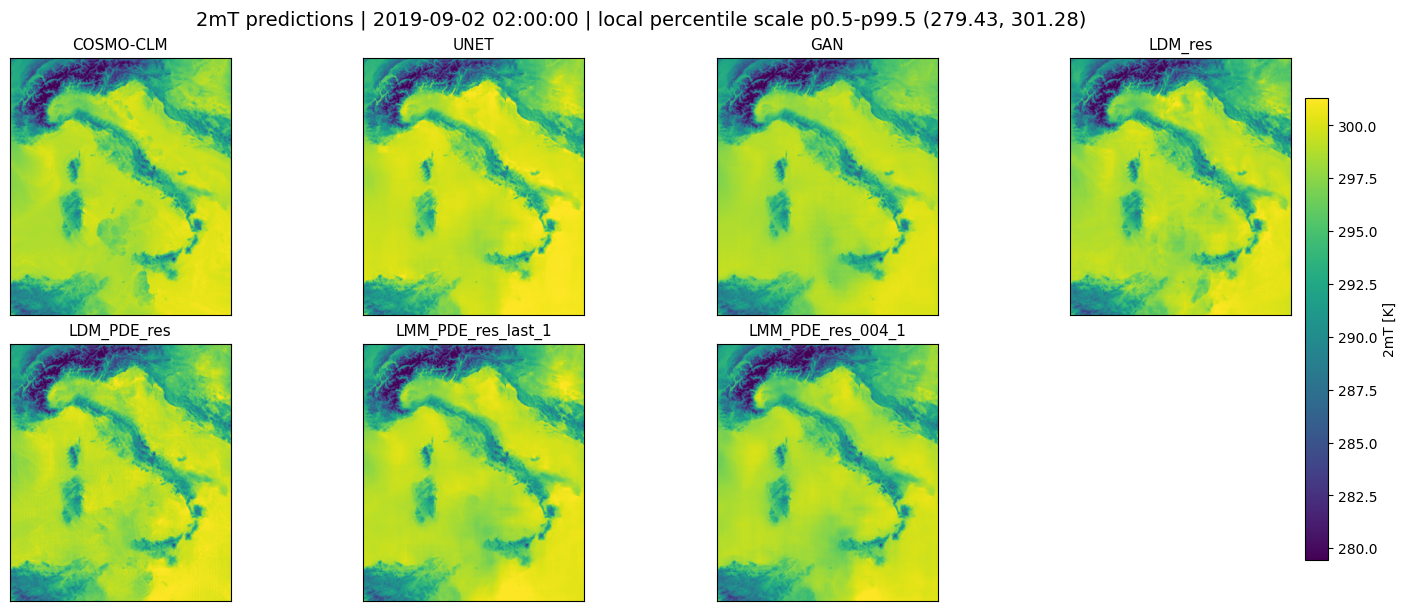

In [24]:
models_to_plot = resolve_models(plot_df, model_order=model_order, exclude=exclude_models)
fixed_vmin, fixed_vmax = color_limits(plot_df)

for ts in selected_times:
    fig, axes = plot_time_slice(
        plot_df,
        ts,
        models=models_to_plot,
        use_fixed_scale=use_fixed_color_scale,
        fixed_vmin=fixed_vmin,
        fixed_vmax=fixed_vmax,
        local_percentiles=local_contrast_percentiles,
        n_rows=n_model_rows,
        figsize_per_panel=(3.8, 3.0),
        # save_path=NOTEBOOK_DIR / f'../outputs/predictions_{ts:%Y%m%d_%H%M}.png',
    )
    plt.show()